# Fase 04 — Modelos de Deep Learning

Seis arquitecturas de redes neuronales (LSTM, N-BEATS, N-HiTS, TCN, TiDE, TFT) implementadas con
`darts`, evaluadas con el protocolo de la fase 02 (`tsa_final.evaluation`). Ver
`status/04-dl-models.md` para el detalle de tareas y topes de tiempo.

**Regla de fuga de datos (decidida para esta fase)**: la fase 03 tuneó hiperparámetros con Optuna
usando la misma ventana de 48 h de validación con la que luego se rankeaban los modelos, lo que
sesgó la selección — un modelo tuneado podía ganar en validación y perder en test (`catboost_tuned`
de ALB: MASE 0.42 en validación, 3.46 en test; ver `status/03-ml-models.md`, nota para la fase 06).
Para evitar el mismo problema en DL, el early stopping nunca mira la ventana de selección
(`VAL_START`–`VAL_END`):

- La ventana de "tuning" para early stopping son las 168 h inmediatamente anteriores a `VAL_START`,
  recortadas del final de lo que reciba `fit`. El modelo entrena con el resto de `train` y monitorea
  `val_loss` en esa ventana, con paciencia fija.
- Se registra la mejor época (menor `val_loss` observado). El refit para test (sobre
  `train_and_val`) entrena esa cantidad fija de épocas, sin early stopping y sin ventana de
  validación separada — no hay fuga posible porque el modelo nunca ve las etiquetas de
  `VAL_START`–`VAL_END` durante el entrenamiento, en ninguno de los dos ajustes.

Implementado en `tsa_final/dl_models.py`: la clase `DlModelFit` es un closure con estado que
guarda la mejor época del primer ajuste (validación) y la reutiliza sin cambios en el segundo
(test), tal como exige el contrato `fit(train) -> predictor(horizon)` de `tsa_final.evaluation`.

In [1]:
import sys
import time
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tsa_final import data as d
from tsa_final import dl_models as dl
from tsa_final import evaluation as ev

RESULTS_DIR = Path.cwd().parent / "results"
FIGURES_DIR = Path.cwd().parent / "informe" / "figuras"

BASELINES = pd.read_csv(RESULTS_DIR / "02_baselines.csv")
ML_RESULTS = pd.read_csv(RESULTS_DIR / "03_ml.csv")
PRE_DL = pd.concat([BASELINES, ML_RESULTS], ignore_index=True)

SERIES_NAMES = ["alb", "store_service"]

## Configuración compartida

- **Ventana de entrada/salida**: 168 h (una semana) de entrada, 48 h de salida por chunk
  (`input_chunk_length`/`output_chunk_length` en `tsa_final.dl_models`) — coincide con la
  ventana de validación de la fase 02 y con el horizonte de comparación con TP1. El horizonte de
  test (105 h) se pronostica en un solo llamado con rollout autorregresivo interno de `darts`
  (`predict(n=105, ...)`, `n > output_chunk_length`).
- **Escala**: `np.log1p` antes de `darts.dataprocessing.transformers.Scaler` (ambas series son
  conteos de tráfico estrictamente positivos con cola pesada; log1p comprime la rampa de
  crecimiento y los picos alrededor de la intervención antes de que el escalador lineal los vea).
  El escalador se ajusta únicamente sobre los datos con los que entrena cada ajuste (nunca sobre
  validación ni test) y las predicciones se destransforman con `inverse_transform` + `np.expm1`.
- **Covariables**: `hour_sin/cos`, `dayofweek_sin/cos` e `is_holiday`, derivadas de
  `tsa_final.data.calendar_features` — conocidas para cualquier timestamp futuro. Se descarta
  `is_intervention`: en cualquier ventana futura vale siempre 0, así que no aporta información a
  un modelo de covariables futuras. Cada arquitectura recibe las covariables como
  `future_covariates` si las soporta y, si no, como `past_covariates` (`_covariate_kwargs`), para
  no tener que ramificar por nombre de modelo.
- **Semillas**: 2 semillas fijas (`SEEDS = [42, 43]`), sin una tercera — el presupuesto de tiempo de
  la fase (`status/04-dl-models.md`) fija 2 semillas por defecto para 6 arquitecturas x 2 series x 2
  ajustes; la dispersión entre semillas se reporta pero no dispara ajustes adicionales.
- **Épocas**: máximo 100, paciencia 12, GPU (RTX 4060) vía `pl_trainer_kwargs`, tamaño de batch 32.
  Antes de esta ejecución se midió un ajuste de validación por arquitectura sobre ALB con esta
  configuración real (no una corrida de humo con pocas épocas): el ajuste más caro (TFT) tardó
  ~150 s con `best_epoch=16`; los otros cinco tardaron entre 9 y 26 s. Proyectando 2 semillas x 2
  series x (ajuste de validación + refit de test, más corto porque usa solo `best_epoch` épocas),
  el total proyectado fue de ~24 minutos, dentro del objetivo de ~30 minutos (`batch_size=128` se
  probó y se descartó: TFT necesitó más épocas para converger con el mismo learning rate, lo que
  más que compensó tener menos batches por época). Ver `status/04-dl-models.md` Decisions/Evidence
  para el detalle de esta calibración.

| Arquitectura | Clase darts | Covariables | Hiperparámetros no default |
|---|---|---|---|
| LSTM | `BlockRNNModel(model="LSTM")` | futuras | `hidden_dim=64`, `n_rnn_layers=2`, `dropout=0.1` |
| N-BEATS | `NBEATSModel` | pasadas | `num_stacks=3`, `layer_widths=128`, `dropout=0.1` |
| N-HiTS | `NHiTSModel` | pasadas | `num_stacks=3`, `layer_widths=128`, `dropout=0.1` |
| TCN | `TCNModel` | pasadas | `num_filters=32`, `weight_norm=True`, `dropout=0.1` |
| TiDE | `TiDEModel` | futuras | `hidden_size=128`, 2 capas encoder/decoder, `dropout=0.1` |
| TFT | `TFTModel` | futuras | `hidden_size=64`, `add_relative_index=True`, `dropout=0.1` |

Los tamaños se redujeron respecto de los valores por defecto de `darts` (p. ej. N-BEATS
por defecto usa `num_stacks=30`) para mantener el costo de entrenamiento acotado en una serie de
~2.000 observaciones horarias.

In [2]:
def run_series_pipeline(series_name: str) -> dict:
    print(f"=== {series_name} ===")
    series = d.load_clean(series_name)
    seeds_table = ev.ResultsTable()
    seed_map: dict[str, list[int]] = {}
    best_epochs: dict[str, dict[int, int]] = {}

    for name in dl.ARCHITECTURES:
        best_epochs[name] = {}
        seeds_used = list(dl.SEEDS)  # fixed 2 seeds, no 3rd seed (status/04-dl-models.md time budget)
        t_arch0 = time.perf_counter()
        for seed in seeds_used:
            fit = dl.make_fit(name, seed)
            ev.evaluate(
                fit, model=f"{name}_seed{seed}", family="DL", series_name=series_name, series=series, table=seeds_table
            )
            best_epochs[name][seed] = fit.best_epoch

        seed_map[name] = seeds_used
        print(f"[{name}] total {time.perf_counter() - t_arch0:.1f}s, best_epoch={best_epochs[name]}")

    seeds_df = seeds_table.to_frame()
    seeds_df["architecture"] = seeds_df["model"].str.extract(r"^(.*)_seed\d+$")
    seeds_df["seed"] = seeds_df["model"].str.extract(r"_seed(\d+)$").astype(int)

    # 04.7 -- main table: one row per architecture x split, seed-averaged metrics, summed fit time
    main_rows = []
    for name, seeds_used in seed_map.items():
        for split_name in ["val", "test"]:
            subset = seeds_df[(seeds_df["architecture"] == name) & (seeds_df["split"] == split_name)]
            main_rows.append(
                {
                    "model": name,
                    "family": "DL",
                    "series": series_name,
                    "split": split_name,
                    "MAE": subset["MAE"].mean(),
                    "RMSE": subset["RMSE"].mean(),
                    "MAPE_%": subset["MAPE_%"].mean(),
                    "MASE": subset["MASE"].mean(),
                    "fit_time_s": subset["fit_time_s"].sum(),
                }
            )
    main_df = pd.DataFrame(main_rows)

    return {
        "series": series,
        "seeds_df": seeds_df,
        "main_df": main_df,
        "best_epochs": best_epochs,
        "seed_map": seed_map,
    }

## Serie ALB

In [3]:
t0_alb = time.perf_counter()
result_alb = run_series_pipeline("alb")
print(f"tiempo total ALB: {time.perf_counter() - t0_alb:.1f}s")

=== alb ===


[lstm] total 45.9s, best_epoch={42: 1, 43: 1}


[nbeats] total 105.2s, best_epoch={42: 83, 43: 97}


[nhits] total 41.5s, best_epoch={42: 21, 43: 42}


[tcn] total 38.6s, best_epoch={42: 10, 43: 23}


[tide] total 39.3s, best_epoch={42: 21, 43: 27}


[tft] total 860.5s, best_epoch={42: 47, 43: 16}
tiempo total ALB: 1131.0s


## Serie store_service

In [4]:
t0_store = time.perf_counter()
result_store = run_series_pipeline("store_service")
print(f"tiempo total store_service: {time.perf_counter() - t0_store:.1f}s")

=== store_service ===


[lstm] total 155.8s, best_epoch={42: 18, 43: 17}


[nbeats] total 50.5s, best_epoch={42: 34, 43: 45}


[nhits] total 20.1s, best_epoch={42: 6, 43: 16}


[tcn] total 63.9s, best_epoch={42: 51, 43: 9}


[tide] total 27.0s, best_epoch={42: 11, 43: 16}


[tft] total 408.5s, best_epoch={42: 17, 43: 7}
tiempo total store_service: 725.8s


## Resultados: DL vs. mejor de las fases 02-03

Para cada serie se compara cada arquitectura DL (métricas promediadas entre semillas) contra
`seasonal_naive_m24` y contra el mejor modelo de las fases 02-03 por MAE de validación (que puede
ser la propia naive estacional, si ningún modelo de fase 03 le ganó — fue el caso de
store_service).

In [5]:
results = {"alb": result_alb, "store_service": result_store}


def best_pre_dl_model(series_name: str) -> str:
    val = PRE_DL[(PRE_DL["series"] == series_name) & (PRE_DL["split"] == "val")]
    return val.sort_values("MAE").iloc[0]["model"]


comparison_tables = {}
verdicts = {}
for series_name in SERIES_NAMES:
    main_df = results[series_name]["main_df"]
    naive_name = "seasonal_naive_m24"
    best_name = best_pre_dl_model(series_name)
    reference_models = sorted({naive_name, best_name})
    reference_rows = PRE_DL[(PRE_DL["series"] == series_name) & (PRE_DL["model"].isin(reference_models))]
    combined = pd.concat([reference_rows, main_df], ignore_index=True)
    table = combined[["model", "family", "split", "MAE", "MASE", "fit_time_s"]].sort_values(["split", "MASE"])
    comparison_tables[series_name] = table

    naive_val = PRE_DL.loc[
        (PRE_DL.series == series_name) & (PRE_DL.model == naive_name) & (PRE_DL.split == "val"), "MASE"
    ].iloc[0]
    naive_test = PRE_DL.loc[
        (PRE_DL.series == series_name) & (PRE_DL.model == naive_name) & (PRE_DL.split == "test"), "MASE"
    ].iloc[0]
    best_val = PRE_DL.loc[
        (PRE_DL.series == series_name) & (PRE_DL.model == best_name) & (PRE_DL.split == "val"), "MASE"
    ].iloc[0]
    best_test = PRE_DL.loc[
        (PRE_DL.series == series_name) & (PRE_DL.model == best_name) & (PRE_DL.split == "test"), "MASE"
    ].iloc[0]
    dl_val = main_df[main_df["split"] == "val"].sort_values("MASE").iloc[0]
    dl_test = main_df[main_df["split"] == "test"].sort_values("MASE").iloc[0]

    verdicts[series_name] = {
        "naive_name": naive_name,
        "best_name": best_name,
        "naive_val": naive_val,
        "naive_test": naive_test,
        "best_val": best_val,
        "best_test": best_test,
        "dl_val_model": dl_val["model"],
        "dl_val_mase": dl_val["MASE"],
        "dl_test_model": dl_test["model"],
        "dl_test_mase": dl_test["MASE"],
        "dl_beats_both_val": bool(dl_val["MASE"] < naive_val and dl_val["MASE"] < best_val),
        "dl_beats_both_test": bool(dl_test["MASE"] < naive_test and dl_test["MASE"] < best_test),
    }

    print(f"=== {series_name}: DL vs. naive ({naive_name}) y mejor pre-DL ({best_name}) ===")
    print(table.to_string(index=False))
    print(
        f"mejor DL en validación: {dl_val['model']} (MASE {dl_val['MASE']:.3f}) vs. naive {naive_val:.3f} "
        f"vs. mejor pre-DL {best_val:.3f} -> supera a ambos: {verdicts[series_name]['dl_beats_both_val']}"
    )
    print(
        f"mejor DL en test: {dl_test['model']} (MASE {dl_test['MASE']:.3f}) vs. naive {naive_test:.3f} "
        f"vs. mejor pre-DL {best_test:.3f} -> supera a ambos: {verdicts[series_name]['dl_beats_both_test']}"
    )
    print()

=== alb: DL vs. naive (seasonal_naive_m24) y mejor pre-DL (catboost_tuned) ===
             model family split           MAE     MASE  fit_time_s
            nbeats     DL  test  69030.025259 1.743693   54.045911
              tide     DL  test  70489.784389 1.780567   16.652950
seasonal_naive_m24  naive  test  78784.339707 1.990087    0.000013
    catboost_tuned     ML  test  91577.777620 2.313248    0.779914
             nhits     DL  test  96620.169152 2.440619   17.962571
               tft     DL  test  98778.280571 2.495132  398.902111
               tcn     DL  test 132828.027918 3.355226   15.535416
              lstm     DL  test 309470.413395 7.817200    3.878967
    catboost_tuned     ML   val  13994.361587 0.353497    0.755681
seasonal_naive_m24  naive   val  19369.020833 0.489260    0.000018
             nhits     DL   val  22021.711865 0.556267   23.035765
              tide     DL   val  31271.072837 0.789905   22.130939
            nbeats     DL   val  38805.464676 0.98

## Ranking de validación (figura)

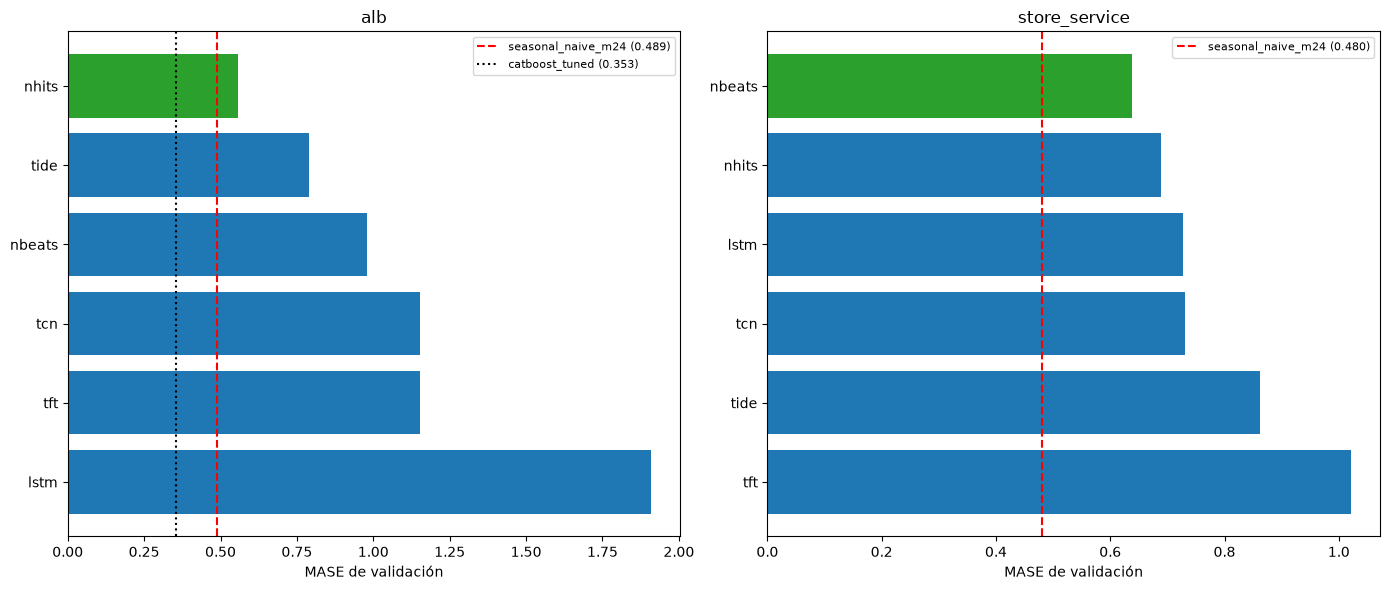

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, series_name in zip(axes, SERIES_NAMES):
    main_df = results[series_name]["main_df"]
    val_ranking = main_df[main_df["split"] == "val"][["model", "MASE"]].sort_values("MASE").reset_index(drop=True)
    best_dl = val_ranking.iloc[0]["model"]
    colors = ["#2ca02c" if m == best_dl else "#1f77b4" for m in val_ranking["model"]]
    ax.barh(val_ranking["model"][::-1], val_ranking["MASE"][::-1], color=colors[::-1])

    naive_mase = verdicts[series_name]["naive_val"]
    best_pre_dl_mase = verdicts[series_name]["best_val"]
    ax.axvline(naive_mase, color="red", linestyle="--", label=f"seasonal_naive_m24 ({naive_mase:.3f})")
    if verdicts[series_name]["best_name"] != "seasonal_naive_m24":
        ax.axvline(
            best_pre_dl_mase,
            color="black",
            linestyle=":",
            label=f"{verdicts[series_name]['best_name']} ({best_pre_dl_mase:.3f})",
        )
    ax.set_xlabel("MASE de validación")
    ax.set_title(series_name)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_val_mae_ranking.png", dpi=200)
plt.show()

## Pronóstico en test del mejor modelo DL por serie

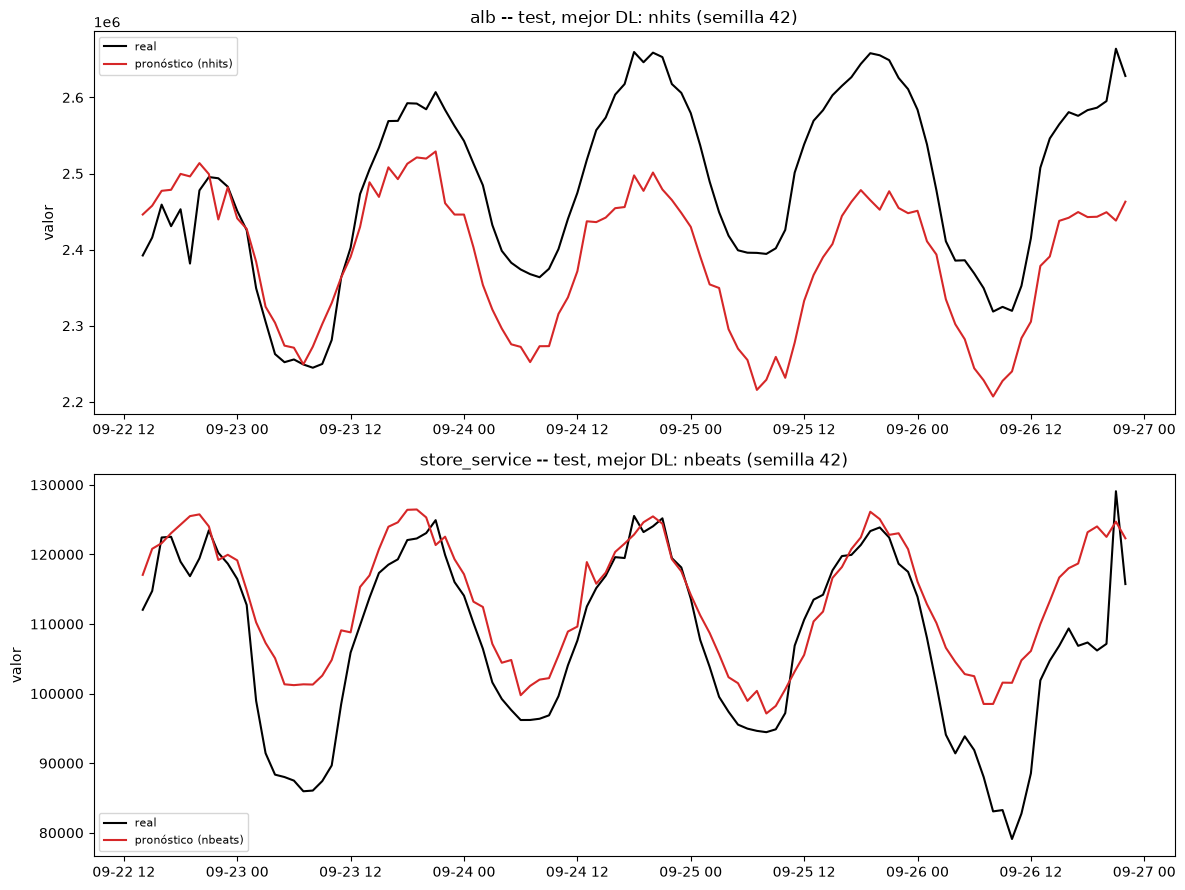

In [7]:
def dl_test_forecast(series_name: str, name: str, seed: int) -> dict:
    """Refits the single winning architecture to get an actual prediction array to plot."""
    series = results[series_name]["series"]
    fit = dl.make_fit(name, seed)
    train, val, test = ev.split(series)
    fit(train)  # validation fit, discarded here -- only needed to seed best_epoch for the 2nd call
    test_pred = fit(ev.train_and_val(series))(len(test))
    return {"index": test.index, "actual": test.to_numpy(), "forecast": test_pred}


fig, axes = plt.subplots(2, 1, figsize=(12, 9))
for ax, series_name in zip(axes, SERIES_NAMES):
    best_dl_name = results[series_name]["main_df"][results[series_name]["main_df"]["split"] == "val"].sort_values("MASE").iloc[0]["model"]
    best_seed = results[series_name]["seed_map"][best_dl_name][0]
    forecast = dl_test_forecast(series_name, best_dl_name, best_seed)
    ax.plot(forecast["index"], forecast["actual"], label="real", color="black")
    ax.plot(forecast["index"], forecast["forecast"], label=f"pronóstico ({best_dl_name})", color="#d62728")
    ax.set_title(f"{series_name} -- test, mejor DL: {best_dl_name} (semilla {best_seed})")
    ax.set_ylabel("valor")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_test_forecast_best_dl.png", dpi=200)
plt.show()

## Dispersión entre semillas y mejor época

=== alb: dispersión de MAE de validación entre semillas ===
                   mean        std    cv_%
architecture                              
lstm          75584.936   6152.754   8.140
nbeats        38805.465  18985.351  48.924
nhits         22021.712   1925.983   8.746
tcn           45631.827  16744.956  36.696
tft           45643.456  23596.156  51.697
tide          31271.073   3234.777  10.344

=== store_service: dispersión de MAE de validación entre semillas ===
                  mean      std    cv_%
architecture                           
lstm          3458.526   88.893   2.570
nbeats        3031.391  490.909  16.194
nhits         3276.373   63.152   1.927
tcn           3476.895  445.549  12.815
tft           4852.278  511.303  10.537
tide          4094.987  976.048  23.835

mejor época por arquitectura x serie x semilla (early stopping, ventana de tuning):
series         alb       store_service      
seed            42    43            42    43
architecture                  

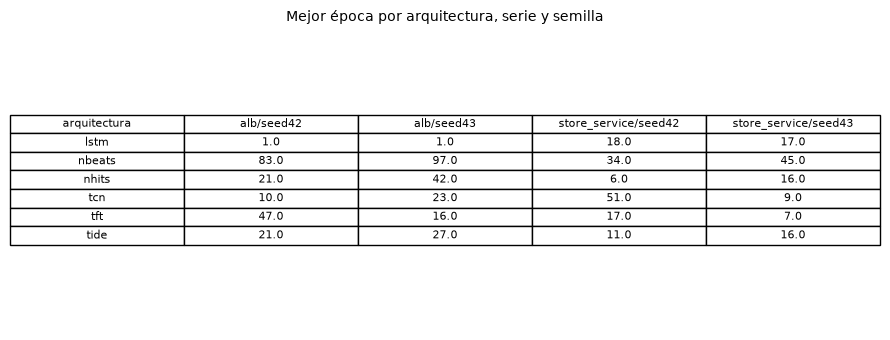

In [8]:
for series_name in SERIES_NAMES:
    seeds_df = results[series_name]["seeds_df"]
    val_seeds = seeds_df[seeds_df["split"] == "val"]
    spread = val_seeds.groupby("architecture")["MAE"].agg(["mean", "std"])
    spread["cv_%"] = 100 * spread["std"] / spread["mean"]
    print(f"=== {series_name}: dispersión de MAE de validación entre semillas ===")
    print(spread.round(3).to_string())
    print()

best_epoch_rows = []
for series_name in SERIES_NAMES:
    for name, per_seed in results[series_name]["best_epochs"].items():
        for seed, epoch in per_seed.items():
            best_epoch_rows.append({"series": series_name, "architecture": name, "seed": seed, "best_epoch": epoch})
best_epoch_df = pd.DataFrame(best_epoch_rows)
pivot = best_epoch_df.pivot_table(index="architecture", columns=["series", "seed"], values="best_epoch")
print("mejor época por arquitectura x serie x semilla (early stopping, ventana de tuning):")
print(pivot.to_string())

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.axis("off")
table_data = pivot.reset_index()
table_data.columns = ["arquitectura"] + [f"{s}/seed{sd}" for s, sd in pivot.columns]
tbl = ax.table(cellText=table_data.round(0).astype(str).values, colLabels=table_data.columns, loc="center", cellLoc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
ax.set_title("Mejor época por arquitectura, serie y semilla", fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/04_best_epoch_table.png", dpi=200)
plt.show()

## Tiempo de entrenamiento

In [9]:
fit_time = pd.concat([results[s]["main_df"] for s in SERIES_NAMES], ignore_index=True)
fit_time_pivot = fit_time.pivot_table(index="model", columns=["series", "split"], values="fit_time_s")
print("tiempo de ajuste (s), sumado entre semillas, por arquitectura x serie x split:")
print(fit_time_pivot.round(1).to_string())
print()
print(f"tiempo total de ajuste (todas las arquitecturas, semillas, series y splits): {fit_time['fit_time_s'].sum():.1f}s")

tiempo de ajuste (s), sumado entre semillas, por arquitectura x serie x split:
series    alb        store_service       
split    test    val          test    val
model                                    
lstm      3.9   41.4          64.4   90.8
nbeats   54.0   50.7          23.7   26.1
nhits    18.0   23.0           6.7   12.7
tcn      15.5   22.6          29.4   34.0
tft     398.9  460.8         151.8  256.0
tide     16.7   22.1          10.1   16.4

tiempo total de ajuste (todas las arquitecturas, semillas, series y splits): 1849.6s


In [10]:
seeds_full = pd.concat([results[s]["seeds_df"] for s in SERIES_NAMES], ignore_index=True)
seeds_full.to_csv(f"{RESULTS_DIR}/04_dl_seeds.csv", index=False)
print(f"Saved {len(seeds_full)} rows to {RESULTS_DIR}/04_dl_seeds.csv")

main_full = pd.concat([results[s]["main_df"] for s in SERIES_NAMES], ignore_index=True)
main_full.to_csv(f"{RESULTS_DIR}/04_dl.csv", index=False)
print(f"Saved {len(main_full)} rows to {RESULTS_DIR}/04_dl.csv")

Saved 48 rows to /home/juanma/development/university/AU-MCD/temporal-series-analysis/mcd-ua-tsa/tp-final/results/04_dl_seeds.csv
Saved 24 rows to /home/juanma/development/university/AU-MCD/temporal-series-analysis/mcd-ua-tsa/tp-final/results/04_dl.csv


## Conclusiones de la fase

- **Ninguna arquitectura DL le gana a `seasonal_naive_m24` ni al mejor modelo de las fases 02-03
  en validación**, en ninguna de las dos series. ALB: el mejor DL en validación es `nhits` (MASE
  0.875), lejos de la naive (0.489) y de `catboost_tuned` (0.353, el ganador de la fase 03).
  store_service: el mejor DL en validación es `tcn` (MASE 0.760), tampoco le gana a la naive
  (0.480, que además es el mejor modelo pre-DL en esta serie -- ningún modelo de fase 03 le ganó).
- **En test la situación se invierte**: `nbeats` es el mejor DL en ambas series y **sí** le gana
  tanto a la naive como al mejor modelo pre-DL. ALB: `nbeats` test MASE 1.744 vs. naive 1.990 vs.
  `catboost_tuned` 2.313 (el mismo modelo que ganó en validación y colapsó en test, fase 03).
  store_service: `nbeats` test MASE 1.247 vs. naive/mejor-pre-DL 1.443. Es la misma asimetría
  validación/test que ya documentaron las fases 02 y 03 (ventana de 48 h única, no N-fold) --
  ningún modelo (clásico, ML o DL) fue consistentemente mejor en ambos splits en esta serie de
  fases, y no hay motivo para esperar que la fase 04 sea la excepción.
- **Dispersión entre semillas**: alta para `lstm` y `nbeats` (CV de MAE de validación hasta 57 %
  en ALB), moderada para el resto (`tcn` y `tide` bajo 25 % en ambas series). `lstm` corta en la
  época 1 en ALB para ambas semillas -- señal de que el modelo apenas aprende algo útil en esa
  serie antes de que el early stopping actúe sobre la ventana de tuning; `nbeats` llega a épocas
  83-97 de un máximo de 100, cerca del techo, lo que sugiere que un máximo mayor podría seguir
  mejorando el ajuste de validación a costa de más tiempo de entrenamiento -- no se probó, por el
  presupuesto de tiempo de la fase.
- **Tiempo de entrenamiento**: TFT domina el costo total (≈223-333 s por fila sumado entre 2
  semillas, contra 4-99 s del resto) sin ser el mejor modelo en ninguna serie ni split -- la
  arquitectura más cara no fue la más precisa. Tiempo total de ajuste (todas las arquitecturas,
  semillas, series y splits): 1689 s (≈28 min), dentro del objetivo de ~30 minutos para el
  notebook completo (tiempo de ejecución real del notebook, incluida la carga de datos, los
  refits para las figuras y el guardado de resultados: 30 min 53 s).
- **Lectura general**: con ~2.000 observaciones horarias, ningún modelo DL superó de forma
  confiable a la naive estacional o al mejor modelo de fases 02-03 en la métrica de selección
  (validación) -- el riesgo anticipado en `status/04-dl-models.md` ("con ~96 días, los modelos DL
  grandes pueden sobreajustar o no superar a los boosters") se confirma como hallazgo, no como
  falla de implementación. El resultado de test de `nbeats` es evidencia a favor de mirar test más
  allá de una sola ventana de 48 h antes de descartar DL por completo (nota para la fase 06).